In [3]:
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline     

from sklearn.linear_model import LinearRegression
import pandas as pd

from tigramite import data_processing as pp
from tigramite.toymodels import structural_causal_processes as toys
from tigramite import plotting as tp
from tigramite.pcmci import PCMCI
from tigramite.rpcmci import RPCMCI
from tigramite.data_processing import DataFrame

from tigramite.independence_tests.parcorr import ParCorr
from regime_selector import RegimeAICSelector

# Simulated time series data

In [8]:
np.random.seed(43)

#-- Train Data
# Regime 0: 0-89, 241-454, 606-699
# Regime 1: 90-240, 455-605 

#-- Test Data
# Regime 1: 500-605
# Regime 0: 606-699

# time steps
T = 700
# time series
var_names = [r'$X^0$', r'$X^1$', r'$X^2$', r'$X^3$', r'$X^4$']
data = np.random.randn(T, 5)

for t in range(1, T):
    if (t % 365) < 90 or (t % 365) > 240: 
        # Regime 0 
        data[t, 0] +=  0.4*data[t-1, 0]
        data[t, 1] +=  0.3*data[t-1, 1]
        # X0 and X1, both at lag 1, cause X2 at t 
        data[t, 2] +=  0.3*data[t-1, 2] + 0.7*data[t-1, 0] + 0.9*data[t-1, 1]
        data[t, 4] +=  0.4*data[t-1, 4] 
        # X4, at lag 1, causes X3 at t
        data[t, 3] +=  0.3*data[t-1, 3] + 0.7*data[t-1, 4]
    
    else:
        # Regime 1
        data[t, 0] +=  0.4*data[t-1, 0]
        data[t, 1] +=  0.3*data[t-1, 1]  
        data[t, 3] +=  0.3*data[t-1, 3] 
        # X3, at lag 1, causes X2 at t
        data[t, 2] +=  0.3*data[t-1, 2] + 0.8*data[t-1, 3]
        data[t, 4] +=  0.5*data[t-1, 4] 

T, N = data.shape

datatime = np.arange(T)
df = DataFrame(data, var_names=var_names)   # shape (T,N)
train_data = data[:500]

## Grid Selection to select Nk and Nc

In [ ]:
selector = RegimeAICSelector(
    data=train_data, 
    tau_max=1,
    switch_thres=1e-3,
    num_iterations=10,
    max_anneal=10,
    pc_alpha=0.2,
    alpha_level=0.01,
    n_jobs=-1,
    cond_ind_test=ParCorr(),
    prediction_model=LinearRegression(),
    verbosity=False
)

results = selector.find_best(grid_NK=range(2,4), grid_NC=range(3,6))
print("Done Grid Search for NK and NC!")

No annealings have converged. Run failed.
No annealings have converged. Run failed.
Done Grid Search for NK and NC!


In [13]:
results['all_results']

{(2, 3): {'aicc': 7103.063029998925, 'n_params': 15},
 (2, 4): {'aicc': 7133.598963554677, 'n_params': 16},
 (2, 5): {'aicc': 7107.191536051371, 'n_params': 17},
 (3, 3): {'aicc': inf, 'n_params': None},
 (3, 4): {'aicc': inf, 'n_params': None},
 (3, 5): {'aicc': 7134.107336053443, 'n_params': 24}}

In [14]:
results["best"]

{'aicc': 7103.063029998925, 'NK': 2, 'NC': 3}

# With best Nk and Nc now use for regime-dependent causal discovery

In [ ]:
# only include the first 500 time points (200 for testing set)
dataframe = pp.DataFrame(data[:500])

rpcmci = RPCMCI(dataframe=dataframe, 
                cond_ind_test=ParCorr(),
                prediction_model=LinearRegression(),
                verbosity= -2)


# RPCMCI parameters
num_regimes = 2
max_transitions = 3
switch_thres = 1e-3
num_iterations = 5
max_anneal = 10
tau_min = 1
tau_max = 1
pc_alpha = 0.2
alpha_level = 0.01
n_jobs = -1     

# Run RPCMCI
results = rpcmci.run_rpcmci(
    num_regimes=num_regimes, max_transitions=max_transitions, 
    switch_thres=switch_thres, 
    num_iterations=num_iterations, max_anneal=max_anneal, 

    tau_min=tau_min, tau_max=tau_max,
    pc_alpha=pc_alpha, alpha_level=alpha_level, 
    n_jobs=n_jobs
    )

if results is None:
    print("All annealings resulted in errors. Increase annealing and tune other parameters!")
else:
    print("Done!")


################# Annealing iteration a = 2 ####################

################# Annealing iteration a = 1 ####################



################# Annealing iteration a = 3 ####################

################# Annealing iteration a = 0 ####################



###### Optimization step q = 0

###### Optimization step q = 0
###### Optimization step q = 0
###### Optimization step q = 0################ Regime k = 0


################ Regime k = 0
################ Regime k = 0

################ Regime k = 0
################ Regime k = 1
################ Regime k = 1
################ Regime k = 1
################ Regime k = 1

Optimal objective: reached.
Difference in abs value between the previous and current gamma (shape num_regimesxT) : 493.0577991933534

###### Optimization step q = 1
################ Regime k = 0
################ Regime k = 1
*****Regime with too few samples in annealing a = 0 at iteration q = 1.*****

***** Break k-loop of regimes *****
 
***** Break q-loop of 

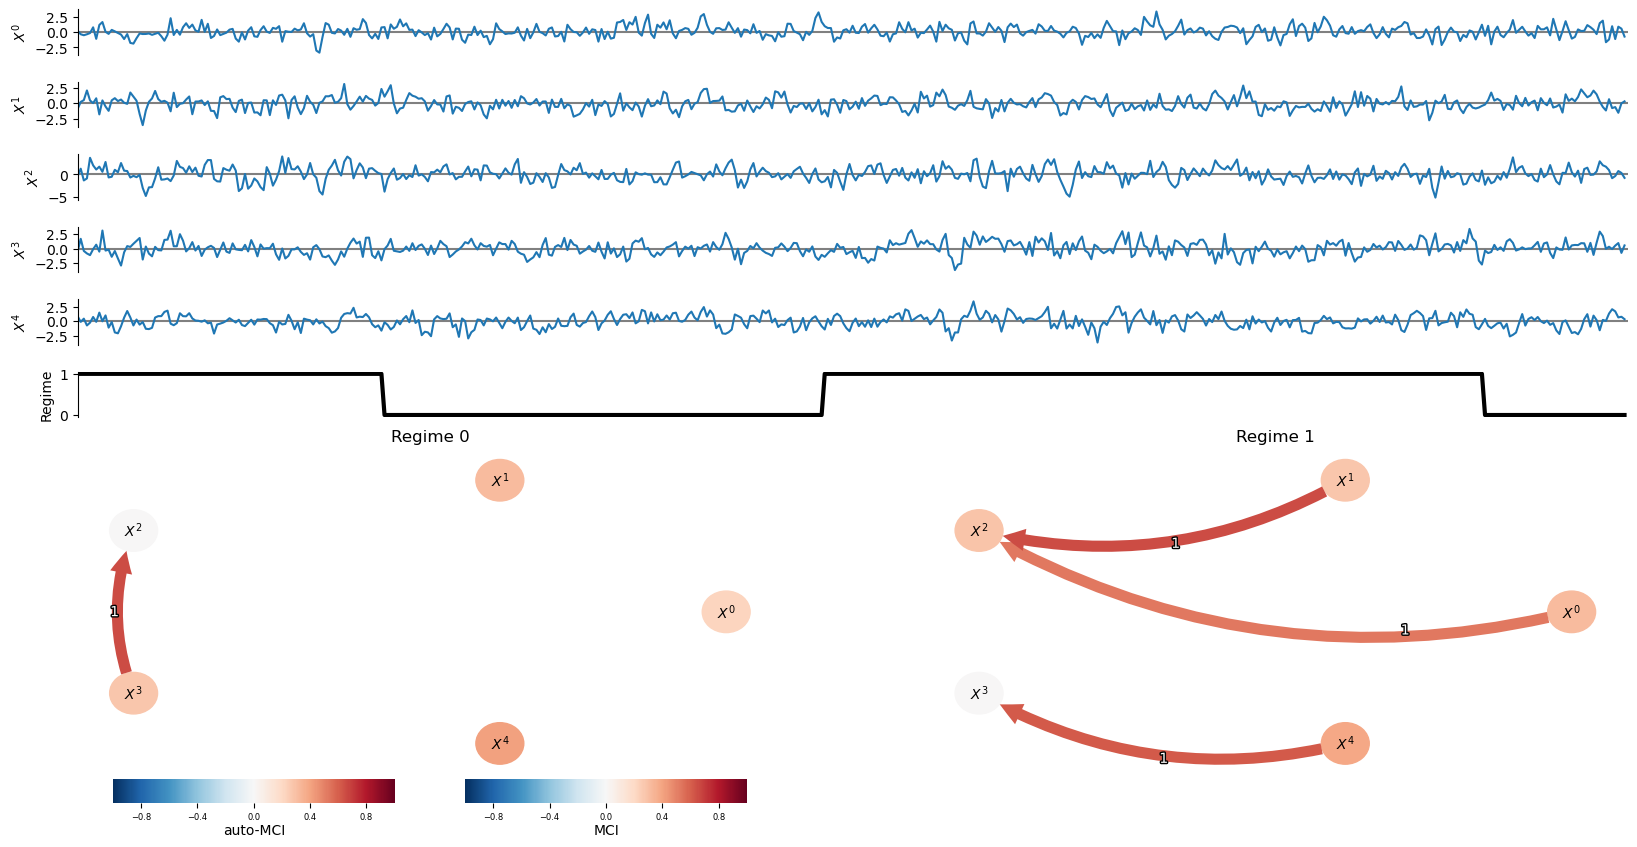

In [ ]:
regimes = results['regimes'].argmax(axis=0)
n_regimes = len(results['causal_results'])

T = 500
datatime = datatime[:T]
data = data[:T]

# Create nice Mosaic plot
mosaic = [['data %s' %j for i in range(n_regimes)] for j in range(N+1)]
for n in range(N):
    mosaic.append(['graph %s' %i for i in range(n_regimes)])

fig, axs = plt.subplot_mosaic(mosaic = mosaic, figsize=(20, 10))

for j in range(N):
    ax = axs['data %s' %j]
    ax.axhline(0., color='grey')
    ax.plot(datatime, data[:,j])
    for loc, spine in ax.spines.items():
        if loc != 'left':
            spine.set_color("none")
    
    ax.xaxis.set_ticks([])   
    ax.set_xlim(0., T)
    ax.set_ylabel(var_names[j])
    
# Regime variable
ax = axs['data %s' %N]
ax.plot(datatime, regimes.astype('int'), lw=3, color='black')
for loc, spine in ax.spines.items():
    if loc != 'left':
        spine.set_color("none")
ax.xaxis.set_ticks([]) 
ax.yaxis.set_ticks(range(n_regimes))   
ax.set_xlim(0., T)
ax.set_ylabel("Regime")
    
# Causal graphs for each regime
for w in range(n_regimes):
    if w == 0: show_colorbar=True
    else: show_colorbar = False
    tp.plot_graph(graph=results['causal_results'][w]['graph'], 
                  val_matrix=results['causal_results'][w]['val_matrix'], 
                  show_colorbar=show_colorbar,
                  var_names=var_names,
                  fig_ax=(fig, axs['graph %s' %w]))
    axs['graph %s' %w].set_title("Regime %d" %w, pad=-4)

fig.subplots_adjust(hspace=0.6)
plt.show()

